# Notebook 6.3 — Patch sizing from spatial autocorrelation (FFT)

**Goal.** Choose the patch size *from the data* instead of guessing it. A patch should be about the size over
which neighbouring voxels are actually related; measure that scale — the **correlation length** — and let it
set the patch. This is a **sizing study only**: stride/overlap and any new noise mechanism are out of scope.

**Why this matters for the wider project.** The patch size fixes `p` (voxels per patch), and `p` fixes how
hard the noise construction is — notebook 6.1 showed privacy needs the *full* rank of the patch, so a bigger
patch is a strictly harder noise problem. So "what size?" is not cosmetic; it sets the difficulty of
everything downstream.

**How to read this notebook.** It is meant to be followed start to finish without outside help. The first two
sections explain the idea and the tool; then six experiments (A–F) each ask one question, show one figure, and
end with a one-line read-off:

- **A** — does the tool even work? (validate it on fields whose length we know)
- **B** — one cubic size, or one per axis?
- **C** — size on the output image, or on the field we actually protect?
- **D** — is one size defensible across the whole brain?
- **E** — real OASIS numbers.
- **F** — size → `p` → the noise dimensionality (the hand-off back to 6.1).

Frozen modules are untouched; every estimator helper lives in this notebook.

*Prerequisites: notebooks 4–5; notebook 6.1 for the dimensionality hand-off in Part F.*

## Background — what we are measuring, and with what

### What is a correlation length?

Take any voxel and its neighbour one step away: their values are usually similar. Two steps away, a bit less
similar. Far enough apart, unrelated. The **correlation length** is a single number for *how far apart two
voxels have to be before they stop being related* — the spatial scale of smoothness.

We read it off the **autocorrelation curve**: for each spatial offset ("lag") we measure how correlated a
voxel is with the voxel that far away, averaged over the whole (masked) volume. That curve starts at 1 at zero
lag (a voxel equals itself) and decays toward 0. A **short** correlation length ⇒ the curve drops fast ⇒ a
rough field. A **long** length ⇒ the curve decays slowly ⇒ a smooth field. Brain gray-matter maps are smooth,
so their length is several voxels — which is exactly why the noise covariance turned out low-rank in 6.1.

### The estimator (the measuring tool)

"The estimator" just means the pipeline that turns *a field* into *a length*. It is three small functions:

1. `masked_acf(x, mask)` — compute the autocorrelation of the field via the FFT (`IFFT(|FFT(x)|²)`, the
   Wiener–Khinchin identity — one FFT per volume, very cheap), **corrected for the brain mask** so the
   zero background and the brain's edge don't bias the result.
2. `axis_profiles(acf)` — read that autocorrelation along each axis, giving one decay curve per axis.
3. `corr_lengths(profile)` — collapse one curve into a single length number.

### Why three length definitions?

"The correlation length" is a *summary of a whole curve*, and there is more than one sensible way to summarize
where a curve decays — so we compute three and pick the convention later:

- **1/e length** — the lag where the curve crosses 0.37 (≈ 1/e). One point on the curve.
- **0.5 length** — the lag where it crosses 0.5. A stricter point (smaller number).
- **integral length** — the area under the whole curve. Uses all of it (robust to noise), with its own
  scaling constant.

They agree on the *shape* of the answer (smoother ⇒ longer, by all three) and differ only in absolute value.
The patch-size mapping `side ≈ c · length` has a free constant `c`, which absorbs that offset — so the choice
matters less for the final size than it looks.

### One thing to keep straight: two different roles for "length"

- In **Part A only** we *set* the length ourselves, to build test fields with a known answer so we can grade
  the estimator. That length is an input we choose.
- **Everywhere else** the length is the *unknown we are measuring* from a field handed to us. We don't know it
  until the estimator tells us.

So "we determine the length ourselves" is true only in A, and only because A is the test rig.

In [1]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import to_rgba
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        sys.path.insert(0, cand); break
import privacy_harness as ph
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3})

# ---------- the estimator: field -> correlation length ----------
def masked_acf(x, mask):
    # Spatial autocorrelation of x inside mask, via FFT, corrected for the mask boundary.
    # FFT assumes the field wraps around periodically, so the zero background and brain edge would
    # bias every length. We zero-pad (no wraparound) and divide by the mask's own autocorrelation
    # (the count of valid voxel pairs at each lag). Returns acf normalized so acf[lag 0] = 1.
    x = np.asarray(x, float); m = np.asarray(mask, float)
    mu = x[m > 0].mean(); xd = (x - mu) * m
    pad = [(0, s) for s in x.shape]
    X = np.fft.fftn(np.pad(xd, pad)); M = np.fft.fftn(np.pad(m, pad))
    num = np.fft.ifftn(np.abs(X)**2).real; den = np.fft.ifftn(np.abs(M)**2).real
    acf = np.where(den > 1e-6, num / np.maximum(den, 1e-9), 0.0)
    return acf / acf.flat[0]

def axis_profiles(acf, max_lag):
    # The 1-D autocorrelation curve along each axis (lag 0..max_lag).
    profs = []
    for ax in range(acf.ndim):
        sl = [slice(0, 1)] * acf.ndim; sl[ax] = slice(0, max_lag)
        profs.append(acf[tuple(sl)].ravel())
    return profs

def corr_lengths(prof):
    # Collapse one autocorrelation curve into three lengths: (1/e crossing, 0.5 crossing, integral).
    def cross(th):                                  # first lag where the curve drops below th (interpolated)
        b = np.where(prof < th)[0]
        if len(b) == 0: return float(len(prof))
        i = b[0]
        return 0.0 if i == 0 else (i-1) + (prof[i-1]-th)/(prof[i-1]-prof[i]+1e-12)
    zc = np.where(prof <= 0)[0]
    integ = prof[:zc[0]].sum() if len(zc) else prof.sum()   # area under the positive part
    return cross(1/np.e), cross(0.5), float(integ)

def lengths_per_axis(x, mask, max_lag=30):
    return [corr_lengths(p) for p in axis_profiles(masked_acf(x, mask), max_lag)]

# ---------- synthetic test fields with a KNOWN length (used only to validate the tool) ----------
def grf(shape, L, seed=0):
    # Gaussian random field with an EXACT Gaussian autocorrelation exp(-r^2 / 2L^2).
    # Because we build it, we know its length analytically: 1/e = L*sqrt2, 0.5 = 1.177*L, integral = 1.253*L.
    rng = np.random.default_rng(seed)
    ks = np.meshgrid(*[np.fft.fftfreq(s)*2*np.pi for s in shape], indexing="ij")
    amp = np.exp(-(L**2)*sum(k**2 for k in ks)/4.0)
    return np.fft.ifftn(np.fft.fftn(rng.standard_normal(shape))*amp).real
print("estimator ready")

estimator ready


## Anatomy of one measurement

Before any experiment, here is the whole idea in one picture. We take a single smooth field, compute its
autocorrelation curve, and mark the three lengths on it — so "correlation length" and "three definitions" stop
being words. The curve falls from 1; the **1/e** and **0.5** lengths are where it crosses those heights; the
**integral** length is the shaded area under it.

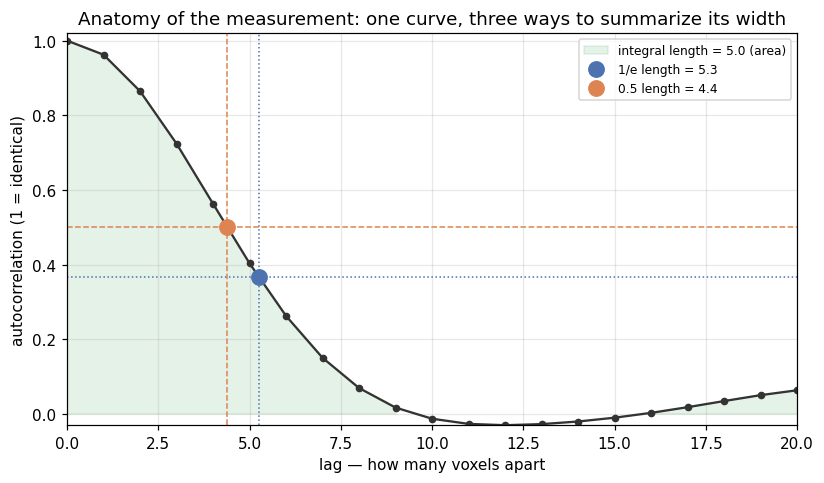

In [2]:
x = grf((64, 64, 64), L=4.0, seed=1)
prof = axis_profiles(masked_acf(x, np.ones((64, 64, 64), bool)), 25)[0]
le, lh, li = corr_lengths(prof); lags = np.arange(len(prof))

fig, ax = plt.subplots(figsize=(7.6, 4.5))
ax.fill_between(lags, 0, prof, where=prof > 0, color="#55a868", alpha=.15, label=f"integral length = {li:.1f} (area)")
ax.plot(lags, prof, "o-", color="#333", ms=4)
ax.axhline(1/np.e, color="#4c72b0", ls=":", lw=1); ax.axvline(le, color="#4c72b0", ls=":", lw=1)
ax.axhline(0.5, color="#dd8452", ls="--", lw=1); ax.axvline(lh, color="#dd8452", ls="--", lw=1)
ax.plot(le, 1/np.e, "o", color="#4c72b0", ms=10, label=f"1/e length = {le:.1f}")
ax.plot(lh, 0.5, "o", color="#dd8452", ms=10, label=f"0.5 length = {lh:.1f}")
ax.set_xlim(0, 20); ax.set_ylim(-0.03, 1.02)
ax.set_xlabel("lag — how many voxels apart"); ax.set_ylabel("autocorrelation (1 = identical)")
ax.set_title("Anatomy of the measurement: one curve, three ways to summarize its width")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## A — Does the tool work? (validate on known ground truth)

On a real brain we have no ground truth, so a biased estimator would go unnoticed. A fixes that: we build
fields whose length we *set* (via `grf`), run the estimator, and check the output matches the value the
formula predicts (`1/e = L·√2`, `0.5 = 1.177·L`, `integral = 1.253·L`). If the tool is unbiased, every point
lands on the diagonal. Passing A checks three things at once: the length is **recovered** (no bias), the
**mask/boundary correction works** (or the points would drift off), and it reveals the tool's **limits**.

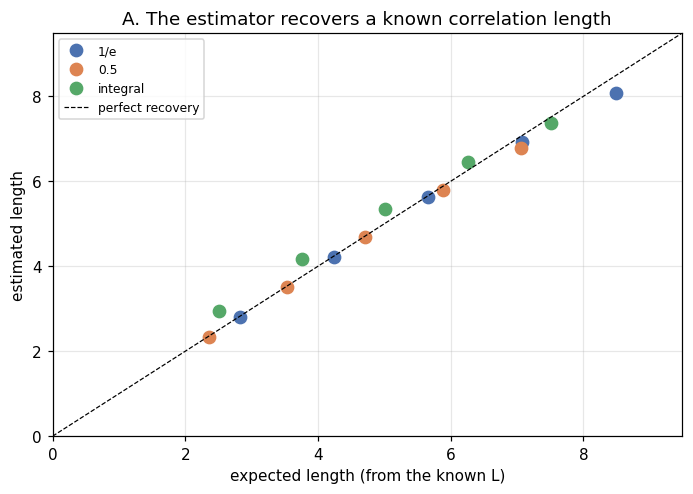

 true_L  est_1/e  exp_1/e  est_0.5  exp_0.5  est_int  exp_int
    2.0     2.81     2.83     2.34     2.35     2.96     2.51
    3.0     4.21     4.24     3.51     3.53     4.16     3.76
    4.0     5.62     5.66     4.68     4.71     5.35     5.01
    5.0     6.93     7.07     5.80     5.88     6.44     6.26
    6.0     8.09     8.49     6.78     7.06     7.38     7.52


In [3]:
Ls = [2.0, 3.0, 4.0, 5.0, 6.0]; m = np.ones((64, 64, 64), bool); rows = []
for L in Ls:
    le, lh, li = corr_lengths(axis_profiles(masked_acf(grf((64,64,64), L, seed=3), m), 30)[0])
    rows.append((L, le, L*np.sqrt(2), lh, 1.177*L, li, 1.253*L))
A = pd.DataFrame(rows, columns=["true_L","est_1/e","exp_1/e","est_0.5","exp_0.5","est_int","exp_int"])

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for est, exp, lbl, c in [("est_1/e","exp_1/e","1/e","#4c72b0"),("est_0.5","exp_0.5","0.5","#dd8452"),
                         ("est_int","exp_int","integral","#55a868")]:
    ax.plot(A[exp], A[est], "o", color=c, ms=8, label=lbl)
lim = [0, A[["est_1/e","exp_1/e"]].values.max()+1]
ax.plot(lim, lim, "k--", lw=.8, label="perfect recovery"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("expected length (from the known L)"); ax.set_ylabel("estimated length")
ax.set_title("A. The estimator recovers a known correlation length"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(A.round(2).to_string(index=False))

**Read-off (A).** The 1/e and 0.5 lengths land on the diagonal; the integral length tracks it on a parallel
line (its own constant). One honest limit, visible at the largest `L`: when the correlation length approaches
the region size, a finite box biases the estimate downward. So lengths are trustworthy when the length is
small relative to the masked region — the realistic regime for brain patches — and to be read with caution
when a field is smooth over a large fraction of the region.

## B — One cubic size, or one per axis?

Two separate choices hide here. **Measuring** a length per axis is always free — the FFT gives a curve per
axis, so we always get `(Lx, Ly, Lz)`. The real decision is whether to **size** per axis: a single cube is
simpler, but if the axes genuinely differ, a cube mis-sizes them. The deciding number is the **anisotropy
ratio** `max(L)/min(L)`: near 1 ⇒ a cube is fine; well above 1 ⇒ use an anisotropic `(kx,ky,kz)`.

Below, a field smoothed differently along each axis (σ = 2, 3.5, 6). **Left:** the three autocorrelation
curves — you can *see* the smoother axis decay slower. **Right:** the per-axis lengths against one cubic size
(the mean across axes) — the cube is wrong for the short *and* the long axis, symmetrically.

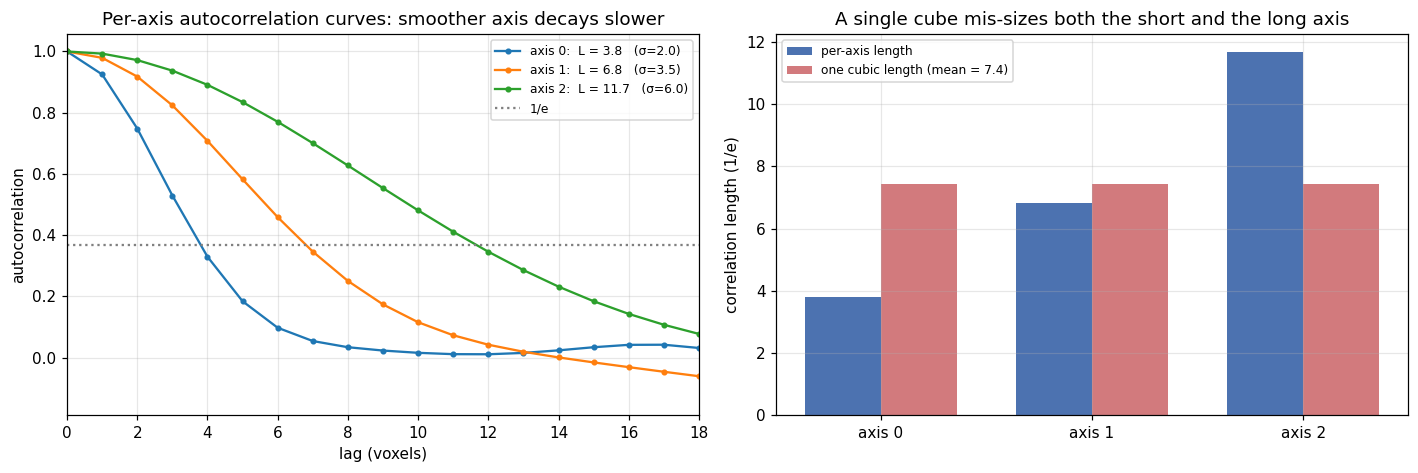

per-axis 1/e lengths: [np.float64(3.81), np.float64(6.81), np.float64(11.66)]  | anisotropy ratio = 3.06


In [4]:
true = [2.0, 3.5, 6.0]
x = gaussian_filter(np.random.default_rng(7).standard_normal((64, 64, 64)), sigma=true, mode="wrap")
profs = axis_profiles(masked_acf(x, np.ones((64,64,64), bool)), 25)
per = [corr_lengths(p)[0] for p in profs]          # 1/e length per axis
iso = float(np.mean(per))                          # one isotropic (cube) length = mean across axes

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for a, (p, L, t) in enumerate(zip(profs, per, true)):
    ax[0].plot(p, "o-", ms=3, label=f"axis {a}:  L = {L:.1f}   (σ={t})")
ax[0].axhline(1/np.e, color="grey", ls=":", label="1/e"); ax[0].set_xlim(0, 18)
ax[0].set_xlabel("lag (voxels)"); ax[0].set_ylabel("autocorrelation")
ax[0].set_title("Per-axis autocorrelation curves: smoother axis decays slower"); ax[0].legend(fontsize=8)

xs = np.arange(3); w = 0.36
ax[1].bar(xs-w/2, per, w, label="per-axis length", color="#4c72b0")
ax[1].bar(xs+w/2, [iso]*3, w, label=f"one cubic length (mean = {iso:.1f})", color=to_rgba("#c44e52", .75))
ax[1].set_xticks(xs); ax[1].set_xticklabels([f"axis {i}" for i in range(3)])
ax[1].set_ylabel("correlation length (1/e)")
ax[1].set_title("A single cube mis-sizes both the short and the long axis"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("per-axis 1/e lengths:", [round(v,2) for v in per], " | anisotropy ratio =", round(max(per)/min(per), 2))

**Read-off (B).** The per-axis lengths separate in proportion to the true per-axis smoothness, and a single
cube (their mean) over-sizes the short axis and under-sizes the long one. So: **always measure per axis**;
**size per axis only when the anisotropy ratio is well above 1**. Two reasons it often will be on real data:
non-cubic voxels (a fixed voxel count is already anisotropic in millimetres — consider sizing in mm), and
genuine directional anatomy.

## C — Size on the output image, or on the field we protect?

We add noise to protect the **perturbation/sensitivity field** — how much each subject moves the release — not
the output image itself. For the linear **mean**, on structure-free data the two fields share a length (a
consistency check); real anatomy breaks that — see the read-off. For a non-linear statistic they differ, so
sizing on the pretty output image could mis-size the field the noise actually has to cover.

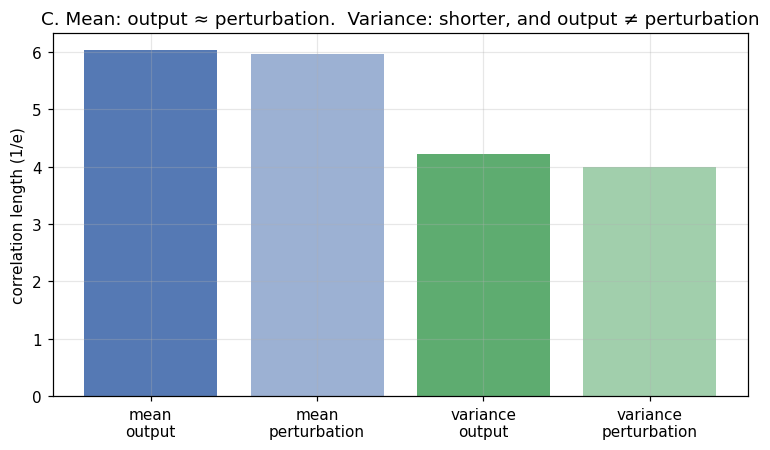

{'mean output': np.float64(6.03), 'mean perturbation': np.float64(5.97), 'variance output': np.float64(4.22), 'variance perturbation': np.float64(3.99)}


In [5]:
shape = (48, 48, 48); m = np.ones(shape, bool); N = 40
subs = np.stack([grf(shape, 4.0, seed=s) for s in range(N)])       # N correlated subjects, true L = 4
mean_out  = subs.mean(0);  mean_pert = (mean_out - subs[0])/(N-1)   # mean, and one LOO perturbation of it
var_out   = subs.var(0);   var_pert  = np.var(np.delete(subs, 0, 0), 0) - var_out
fields = {"mean\noutput": mean_out, "mean\nperturbation": mean_pert,
          "variance\noutput": var_out, "variance\nperturbation": var_pert}
Lvals = {k: corr_lengths(axis_profiles(masked_acf(v, m), 30)[0])[0] for k, v in fields.items()}

plt.figure(figsize=(7, 4.2))
cols = [to_rgba(b, a) for b, a in zip(["#4c72b0","#4c72b0","#55a868","#55a868"], [.95,.55,.95,.55])]
plt.bar(range(4), list(Lvals.values()), color=cols)
plt.xticks(range(4), list(fields)); plt.ylabel("correlation length (1/e)")
plt.title("C. Mean: output ≈ perturbation.  Variance: shorter, and output ≠ perturbation")
plt.tight_layout(); plt.show()
print({k.replace(chr(10),' '): round(v,2) for k, v in Lvals.items()})

**Read-off (C).** For the mean, output and perturbation give the same length *here* — but only because these
synthetic subjects share no large-scale structure. On real data the mean image also carries the **anatomical
envelope** common to all subjects, whose long autocorrelation inflates the image length; that envelope
**cancels** in the LOO perturbations (`dᵢ ∝ mean − xᵢ`), so image and perturbation diverge even for the linear
mean — this is exactly what blows the naive patch size up in F. For the **variance** the field is shorter *and*
output ≠ perturbation regardless. Decision this supports, now for **every** statistic: **size on the
perturbation/sensitivity field**, not the output image.

## D — Is one size defensible across the whole brain?

Everything so far produced **one length for the whole volume**. But smoothness varies by position — cortex,
white matter and ventricles are not equally smooth — so a whole-brain length is really a *spatial average*,
and averaging an autocorrelation across different regions can mislead. This is a deliberately minimal two-region
check: does a single global size represent the regions, or neither?

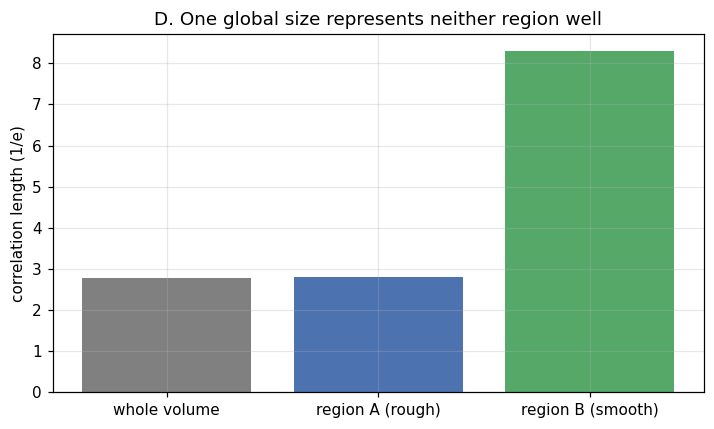

{'whole volume': np.float64(2.77), 'region A (rough)': np.float64(2.8), 'region B (smooth)': np.float64(8.29)}


In [6]:
shape = (48, 48, 48)
vol = np.empty(shape)
vol[:24] = grf(shape, 2.0, seed=10)[:24]           # region A: rough (short length)
vol[24:] = grf(shape, 6.0, seed=11)[24:]           # region B: smooth (long length)
regions = {"whole volume": np.ones(shape, bool)}
regions["region A (rough)"] = np.zeros(shape, bool); regions["region A (rough)"][:24] = True
regions["region B (smooth)"] = np.zeros(shape, bool); regions["region B (smooth)"][24:] = True
Lreg = {k: corr_lengths(axis_profiles(masked_acf(vol, mm), 30)[0])[0] for k, mm in regions.items()}

plt.figure(figsize=(6.6, 4))
plt.bar(range(3), list(Lreg.values()), color=["grey", "#4c72b0", "#55a868"])
plt.xticks(range(3), list(Lreg)); plt.ylabel("correlation length (1/e)")
plt.title("D. One global size represents neither region well")
plt.tight_layout(); plt.show()
print({k: round(v,2) for k, v in Lreg.items()})

**Read-off (D).** The two regions have clearly different lengths, and the global estimate matches neither (the
boundary and the rougher region dominate it). So **"one size everywhere" is a claim to defend, not a given.**
Kept minimal here; whether real brain smoothness varies enough to force region-specific sizing is an empirical
question for OASIS — the honest next diagnostic is a *local* smoothness map (a sliding window), which we add
only if this turns out to matter.

## E — Real OASIS

The same estimator on real gray-matter maps. Set `USE_OASIS = True` in an environment with `nilearn`; here it
falls back to a synthetic multi-axis field so the section runs anywhere. On OASIS this reports the per-axis
lengths (all three definitions) and the raw autocorrelation curves, with the estimator's own limits from A in
mind.

substrate: synthetic (OASIS unavailable: No module named 'nilearn')   (mask covers 40% of the volume)
  axis 0:  1/e = 5.76   0.5 = 4.85   integral = 5.46
  axis 1:  1/e = 7.16   0.5 = 6.15   integral = 6.56
  axis 2:  1/e = 12.61   0.5 = 10.51   integral = 11.09


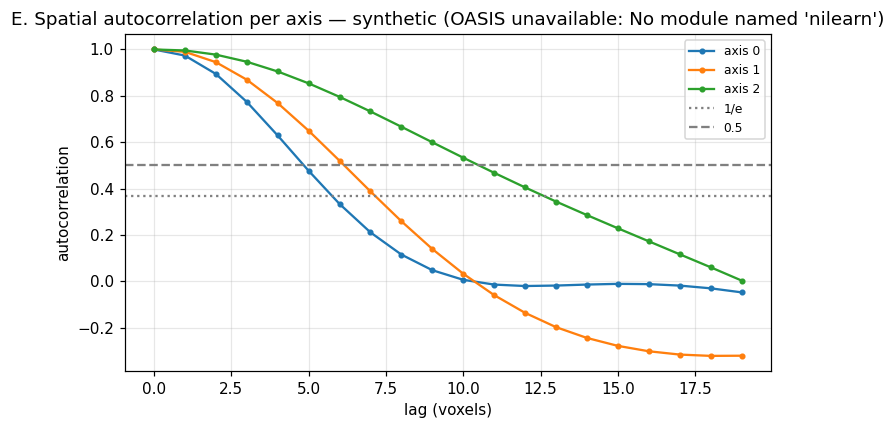

In [7]:
USE_OASIS = True                                   # set True where nilearn + network are available
note = None
if USE_OASIS:
    try:
        vols, mask = ph.load_oasis(n=40); note = "OASIS gray-matter maps"
    except Exception as e:
        USE_OASIS = False; note = f"synthetic (OASIS unavailable: {e})"
if not USE_OASIS:
    shape = (48, 48, 48)
    vols = np.stack([gaussian_filter(np.random.default_rng(s).standard_normal(shape),
                                     sigma=(3.0, 4.0, 5.5), mode="wrap") for s in range(40)])
    cc = np.stack(np.meshgrid(*[np.arange(48)-24]*3, indexing="ij")); mask = (cc**2).sum(0) < 22**2
    note = note or "synthetic stand-in (sphere mask, anisotropic)"

out_field = vols.mean(0)                             # the released mean map
print(f"substrate: {note}   (mask covers {mask.mean()*100:.0f}% of the volume)")
for ax, (le, lh, li) in enumerate(lengths_per_axis(out_field, mask)):
    print(f"  axis {ax}:  1/e = {le:.2f}   0.5 = {lh:.2f}   integral = {li:.2f}")
acf = masked_acf(out_field, mask)
plt.figure(figsize=(6.8, 4))
for ax, prof in enumerate(axis_profiles(acf, 20)):
    plt.plot(prof, "o-", ms=3, label=f"axis {ax}")
plt.axhline(1/np.e, color="grey", ls=":", label="1/e"); plt.axhline(0.5, color="grey", ls="--", label="0.5")
plt.xlabel("lag (voxels)"); plt.ylabel("autocorrelation"); plt.legend(fontsize=8)
plt.title(f"E. Spatial autocorrelation per axis — {note}"); plt.tight_layout(); plt.show()

## F — Size → dimensionality → hand-off to the noise construction

The pay-off, and where this notebook stops. A measured length becomes a patch side through `side ≈ c · L`,
where **`c`** is a design knob — how many correlation lengths wide the patch is, chosen not derived — fixed
here as `C_SIDE`. Crucially, we measure `L` on the **sensitivity field** `S(v) = maxᵢ|dᵢ|` — the field the
noise actually has to cover (finding C) — not on the mean output image. On real data that distinction is not
cosmetic: the mean image carries the large-scale **anatomical envelope** shared across subjects, whose long
autocorrelation would inflate `L` and blow the patch up to tens of voxels a side; that envelope **cancels** in
the LOO perturbations, so `S` reports the local scale the mechanism must protect. We build the patch **two
ways** to compare: a **cubic** side from the mean 1/e length, and an **anisotropic per-axis** patch
(`side_ax ≈ c · L_ax`, following finding B).

Each gives a voxel count `p`, and the noise construction must cover `min(p, N−1)` dimensions — the rank ceiling
of the LOO covariance. *Why the full `min(p, N−1)` rank and not the 95%-variance effective rank is notebook
6.1's result — the membership signal fills the whole LOO subspace; carried across here, not re-argued.*

At OASIS scale (`N ≈ 40`) `p ≫ N−1` for any sensible patch, so the two geometries differ in `p` — the number
of voxels to tile, hence acceptance/fallback difficulty — while the dimensionality the noise must span pins to
`N−1` either way. That is the hand-off to the noise construction.

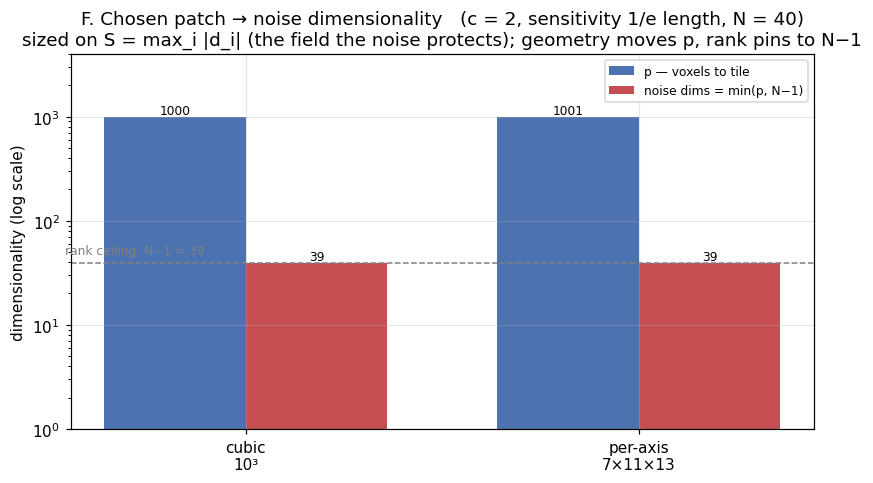

sized on the sensitivity field S(v)=max_i|d_i| (mean pipeline) · c = C_SIDE = 2

   patch side(s) sensitivity 1/e length(s)    p  noise dims = min(p, N-1)
   cubic    10^3                       5.2 1000                        39
per-axis 7x11x13             3.6, 5.4, 6.5 1001                        39


In [8]:
# --- F. Chosen patch -> noise dimensionality, sized on the SENSITIVITY field (finding C) ---
C_SIDE    = 2.0                       # design knob: patch side = C_SIDE * (1/e length). A choice, not derived.
N         = int(vols.shape[0])
RANK_CEIL = N - 1                     # the LOO covariance has at most N-1 non-zero modes (the rank ceiling)

# Size on the field the noise protects, NOT the mean image: the mean image carries the shared anatomical
# envelope (long length) that cancels in the LOO perturbations. S(v)=max_i|d_i| is what the mechanism keys on.
_, _, S_field = ph.loo_artifacts(vols, ph.pipeline_mean)

LE     = [t[0] for t in lengths_per_axis(S_field, mask)]     # per-axis 1/e lengths of the sensitivity field
L_cube = float(np.mean(LE))                                  # isotropic summary length for a cubic patch
side   = lambda L: max(2, int(round(C_SIDE * L)))
side_cube, sides_ax = side(L_cube), [side(L) for L in LE]

p_cube, p_ax       = side_cube**3, int(np.prod(sides_ax))
dims_cube, dims_ax = min(p_cube, RANK_CEIL), min(p_ax, RANK_CEIL)

tbl = pd.DataFrame({"patch": ["cubic", "per-axis"],
                    "side(s)": [f"{side_cube}^3", "x".join(map(str, sides_ax))],
                    "sensitivity 1/e length(s)": [f"{L_cube:.1f}", ", ".join(f"{L:.1f}" for L in LE)],
                    "p": [p_cube, p_ax],
                    "noise dims = min(p, N-1)": [dims_cube, dims_ax]})

fig, ax = plt.subplots(figsize=(7.6, 4.5))
xpos, w = np.arange(2), 0.36
groups = [f"cubic\n{side_cube}\u00b3", "per-axis\n" + "\u00d7".join(map(str, sides_ax))]
bp = ax.bar(xpos - w/2, [p_cube, p_ax],       w, color="#4c72b0", label="p \u2014 voxels to tile")
bd = ax.bar(xpos + w/2, [dims_cube, dims_ax], w, color="#c44e52", label="noise dims = min(p, N\u22121)")
ax.axhline(RANK_CEIL, color="grey", ls="--", lw=1)
ax.text(-0.46, RANK_CEIL*1.15, f"rank ceiling  N\u22121 = {RANK_CEIL}", color="grey", fontsize=8, va="bottom")
ax.set_yscale("log"); ax.set_ylim(1, max(p_cube, p_ax) * 4)
ax.set_xticks(xpos); ax.set_xticklabels(groups)
ax.set_ylabel("dimensionality (log scale)")
ax.set_title(f"F. Chosen patch \u2192 noise dimensionality   (c = {C_SIDE:g}, sensitivity 1/e length, N = {N})\n"
             "sized on S = max_i |d_i| (the field the noise protects); geometry moves p, rank pins to N\u22121")
for b in list(bp) + list(bd):
    ax.annotate(f"{int(b.get_height())}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=8)
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()
print(f"sized on the sensitivity field S(v)=max_i|d_i| (mean pipeline) \u00b7 c = C_SIDE = {C_SIDE:g}\n")
print(tbl.to_string(index=False))

## Conclusions & open decisions

- **The tool is validated** (A): FFT autocorrelation with mask correction recovers a known length to a few
  percent in the realistic short-length regime, and degrades gracefully (a caveat to report) when the length
  nears the region size.
- **Measure per axis always; size per axis when anisotropic** (B): the per-axis lengths separate with the true
  structure; a cube mis-sizes when the ratio is well above 1.
- **Size on the perturbation field, not the image** (C): they agree for the mean but diverge for non-linear
  statistics, and the perturbation field is what the noise protects.
- **One global size is a claim to defend** (D): regions differ, and the global estimate represents neither.
- **Sizing sets the noise dimensionality** (F): `side ≈ c·L → p`; the noise must then cover
  `min(p, N−1)` dimensions (the full-rank requirement is notebook 6.1's result, carried across here, not
  re-argued). At OASIS scale `p ≫ N−1`, so patch geometry moves `p` — the tiling and fallback difficulty
  — while the rank the noise spans pins to `N−1`.

**Deferred, as agreed:** we report **both** length definitions and pick after seeing OASIS; **stride/overlap**
is a separate study (with a privacy-compounding angle); and **position-dependent sizing** (a local smoothness
map) is the natural extension of D — built only if OASIS shows the smoothness varies enough to matter.

**To turn this into real numbers before the meeting:** set `USE_OASIS = True` and re-run E and F. The
structural conclusions are dataset-general; only the absolute lengths and `p` change. *No DP guarantees;
this notebook sizes patches, it does not make privacy claims.*